In [1]:
import datetime
import sys, os, logging
from pathlib import Path

from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import pyarrow.feather as feather
import matplotlib.pyplot as plt
%matplotlib inline 


logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")

# Project root
PROJECT_ROOT = Path(os.path.abspath("../../.."))
sys.path.insert(0, str(PROJECT_ROOT))

from inference.prefilter_model.utils import (
    list_h5_parts, load_model, load_mc_test_parts,
    load_exp_parts, load_mc_reco_parts, predict_scores,
    plot_event_3d, load_blind_reco,
    EXP_RECO_COL_NAMES, MC_RECO_COL_NAMES, COMMON_RECO_COLS,
)

%load_ext autoreload
%autoreload 2

In [2]:
MODEL_NAME = "da_prefilter_numu_260430_0846_Qclip_hardlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_FocalLoss"
SAVE_DIR = Path(f"./{MODEL_NAME}")

# ── Figures output directory ──
FIGURES_DIR = PROJECT_ROOT / f"experiments/numu/{MODEL_NAME}/figures_test_mcexpreco"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, filename: str, rewrite=True) -> None:
    """Save figure to FIGURES_DIR; raise FileExistsError if already present."""
    fig_path = FIGURES_DIR / filename
    if not rewrite and fig_path.exists():
        raise FileExistsError(f"Figure already exists: {fig_path}")
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {fig_path}")

def get_mask(df, theta_cuts=(0, 30)):
    theta_mask = (df['thetaRec'] > theta_cuts[0]) & (df['thetaRec'] <= theta_cuts[1]) & (df['scfMaxTheta'] < (theta_cuts[1]*1.2)/180*3.1428)
    theta_mask_conj = ~theta_mask
    
    mask = np.ones(len(df), dtype=bool)
    mask = mask & (df['nHits'] >= 8)
    mask = mask & (df['nStrings'] >= 3)
    mask = mask & (df['covMatrixStatus'] == 3)
    mask = mask & (np.log10(df['pHit']) > -9.)
    mask = mask & (df['evCenterZ'] < 220)
    mask = mask & (df['zDist'] > 70)
    mask = mask & (df['pathLength'] > 50)
    mask = mask & (np.log10(df['funcValue'] / (df['nHits'] - 5)) < 2.)
    mask = mask & (df['nTriplets'] / df['nHits'] > 0.1)
    mask = mask & (df['thetaErr'] < 2.5)
    mask = mask & (df['nCalls'] < 350)
    return mask&theta_mask, mask&theta_mask_conj

In [3]:
# JOIN_KEYS  = ["h5_part_str", "local_id"]  # match scalars ↔ arrays

# df_exp_scalars = pd.read_parquet(SAVE_DIR / "exp.parquet")
# df_mc_scalars = pd.read_parquet(SAVE_DIR / "mc.parquet")

import pyarrow.parquet as pq

ARRAY_COLS = {"features", "signal_mask", "reco_hit_prty"}

# Inspect available columns without reading data
schema = pq.read_schema(SAVE_DIR / "exp.parquet")
scalar_cols = [c for c in schema.names if c not in ARRAY_COLS]
# Read only scalar columns — array columns never touch RAM
df_exp_scalars = pq.read_table(SAVE_DIR / "exp.parquet", columns=scalar_cols).to_pandas()
print("Exp reco loaded.")

# Inspect available columns without reading data
mc_names = ["mc.parquet", "mc_scalars.parquet"]
if Path.exists(SAVE_DIR / "mc.parquet"):
    mc_preds_name = "mc.parquet"
elif Path.exists(SAVE_DIR / "mc_scalars.parquet"):
    mc_preds_name = "mc_scalars.parquet"

schema = pq.read_schema(SAVE_DIR / mc_preds_name)
scalar_cols = [c for c in schema.names if c not in ARRAY_COLS]
# Read only scalar columns — array columns never touch RAM
df_mc_scalars = pq.read_table(SAVE_DIR / mc_preds_name, columns=scalar_cols).to_pandas()
print("MC reco loaded.")

Exp reco loaded.
MC reco loaded.


In [4]:
df_exp_scalars = df_exp_scalars[(df_exp_scalars['cluster']!=1)]
df_mc_scalars = df_mc_scalars[~(df_mc_scalars['h5_part_str'].str.contains('cl1'))]

## Filter events having max Q >1e4 ev
if 'max_q' in df_exp_scalars.columns:
    maxq = df_exp_scalars['max_q']
    df_exp_scalars = df_exp_scalars[maxq <= 1e4]#.reset_index(drop=True)

In [5]:
if False:
    print("Loading hit masks for exp...")
    temp_arrays  = feather.read_table(SAVE_DIR / "exp_arrays.arrow", columns=JOIN_KEYS + ['signal_mask', 'reco_hit_prty']).to_pandas()
    nhits_gt = temp_arrays['signal_mask'].apply(sum)
    nhits_reco = temp_arrays['reco_hit_prty'].apply(sum)
    #df_exp = df_exp_scalars.merge(df_exp_arrays, on=JOIN_KEYS)

    print("Loading hit masks for mc...")
    df_mc_arrays  = feather.read_table(SAVE_DIR / "exp_arrays.arrow", columns=JOIN_KEYS + ['signal_mask', 'reco_hit_prty']).to_pandas()
    #df_mc = df_mc_scalars.merge(df_mc_arrays, on=JOIN_KEYS)

    print("Done.")

/home/albert/miniconda3/envs/baikal25/lib/python3.10/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


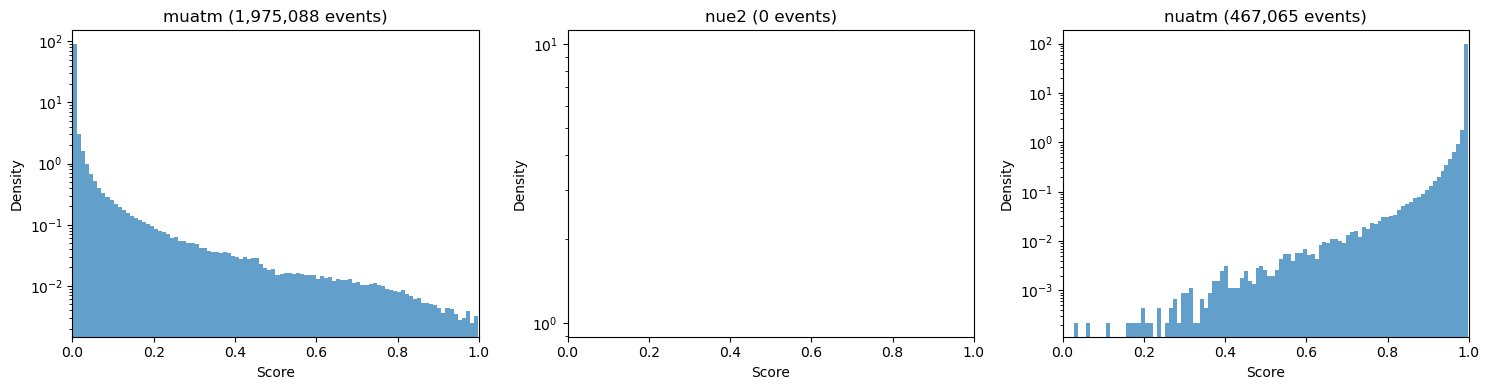

Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260430_0846_Qclip_hardlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_test_mcexpreco/score_dist_per_particle.png
Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260430_0846_Qclip_hardlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_test_mcexpreco/preds_distr_mcexp_reco_cuts_theta(0, 80).png


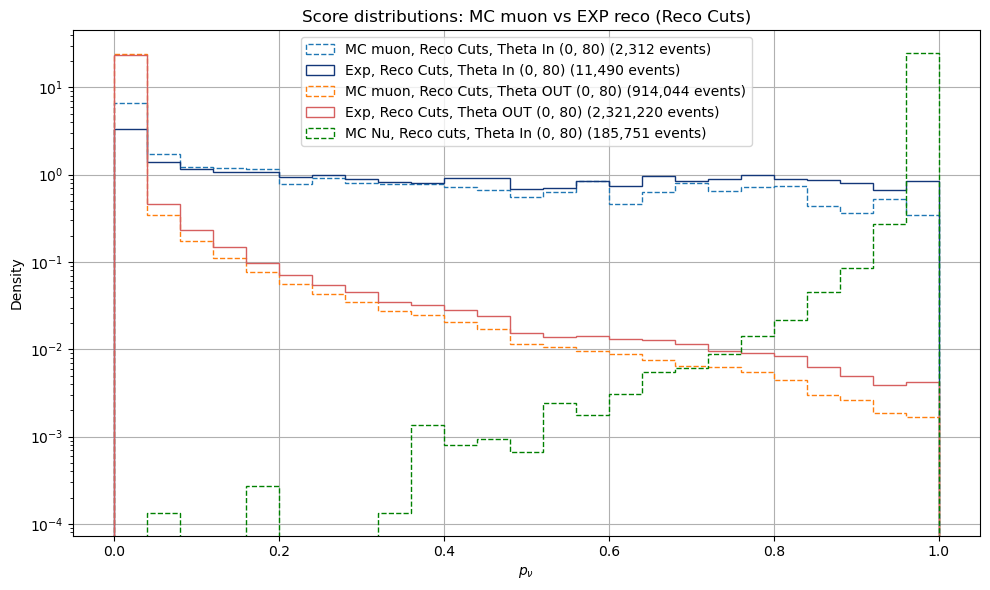

Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260430_0846_Qclip_hardlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_test_mcexpreco/preds_distr_mcexp_reco_cuts_theta(0, 90).png


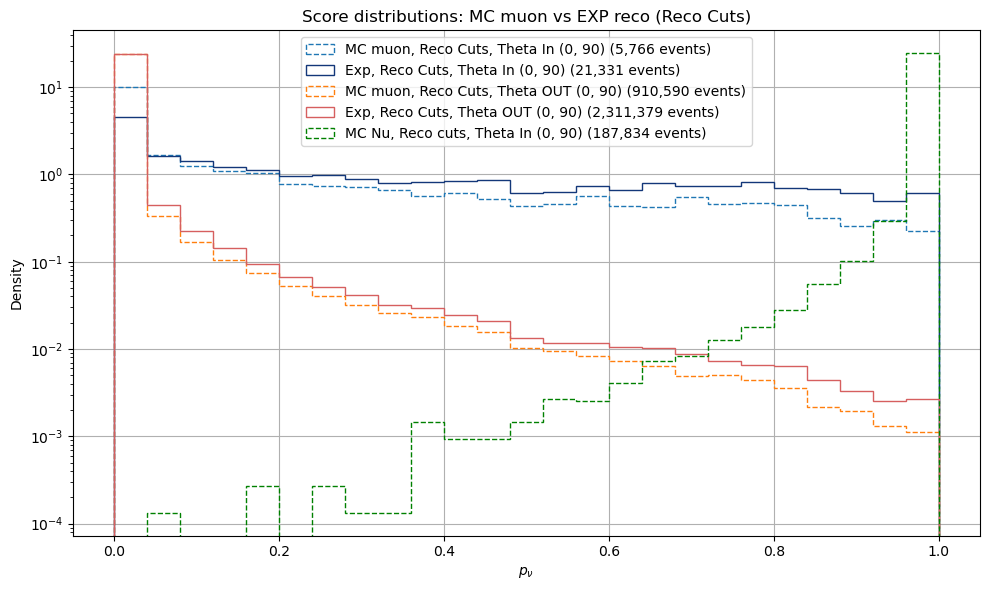

In [6]:
%matplotlib inline
MASK_BUGS_MC = (df_mc_scalars['n_signal_hits_gt']>=6) # Filter Multi Cluster events artifacts


plt.close()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Score distribution per particle type
for ax, ptype in zip(axes, ["muatm", "nue2", "nuatm"]):
    sub = df_mc_scalars[df_mc_scalars["particle_type"].str.startswith(ptype) & MASK_BUGS_MC]
    ax.hist(sub["score"], bins=100, alpha=0.7, log=True, density=True)
    ax.set_title(f"{ptype} ({len(sub):,} events)")
    ax.set_xlabel("Score")
    ax.set_ylabel("Density")
    ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()
save_figure(fig, "score_dist_per_particle.png")

for THETA_CUTS in [(0,80), (0,90)]:
    mask_exp, mask_exp_conj = get_mask(df_exp_scalars, theta_cuts=THETA_CUTS)
    mask_mc, mask_mc_conj = get_mask(df_mc_scalars, theta_cuts=THETA_CUTS)

    # Score distribution: MC muons vs MC neutrinos vs Exp
    mu = df_mc_scalars[(df_mc_scalars["particle_type"].str.startswith("muatm")) & mask_mc & MASK_BUGS_MC]["score"]
    mu_conj = df_mc_scalars[(df_mc_scalars["particle_type"].str.startswith("muatm")) & mask_mc_conj & MASK_BUGS_MC]["score"]
    nu = df_mc_scalars[(df_mc_scalars["particle_type"].str.startswith("nu")) & mask_mc & MASK_BUGS_MC]["score"]
    nu_conj = df_mc_scalars[(df_mc_scalars["particle_type"].str.startswith("nu")) & mask_mc_conj & MASK_BUGS_MC]["score"]
    exp_reco = df_exp_scalars["score"][mask_exp]
    exp_reco_conj = df_exp_scalars["score"][mask_exp_conj]
    

    fig, ax = plt.subplots(figsize=(10, 6))
    B = 25
    ax.hist(mu, bins=B, range=(0,1), histtype='step', ls='--', log=True, density=True, label=f"MC muon, Reco Cuts, Theta In {THETA_CUTS} ({len(mu):,} events)")
    ax.hist(exp_reco, bins=B, range=(0,1), histtype='step', color="#133779", log=True, density=True, label=f"Exp, Reco Cuts, Theta In {THETA_CUTS} ({len(exp_reco):,} events)")

    ax.hist(mu_conj, bins=B, range=(0,1), histtype='step', ls='--', log=True, density=True, label=f"MC muon, Reco Cuts, Theta OUT {THETA_CUTS} ({len(mu_conj):,} events)")
    ax.hist(exp_reco_conj, range=(0,1), bins=B, histtype='step', color="#D65F5F", log=True, density=True, label=f"Exp, Reco Cuts, Theta OUT {THETA_CUTS} ({len(exp_reco_conj):,} events)")
    
    ax.hist(nu, bins=B, range=(0,1), histtype='step', ls='--', color='green', log=True, density=True, label=f"MC Nu, Reco cuts, Theta In {THETA_CUTS} ({len(nu):,} events)")
    
    ax.set_xlabel(r"$p_\nu$")
    ax.set_ylabel("Density")
    ax.legend()
    ax.set_title("Score distributions: MC muon vs EXP reco (Reco Cuts)")
    ax.grid()
    plt.tight_layout()
    save_figure(fig, f"preds_distr_mcexp_reco_cuts_theta{THETA_CUTS}.png")
    plt.show()


Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260430_0846_Qclip_hardlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_test_mcexpreco/preds_distr_mcexp_reco_cuts_theta(0, 180).png


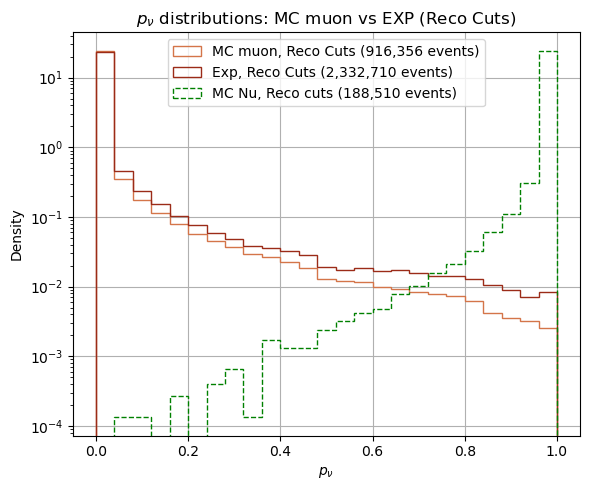

In [7]:
THETA_CUTS = (0, 180)

mask_exp, _ = get_mask(df_exp_scalars, theta_cuts=THETA_CUTS)
mask_mc, _ = get_mask(df_mc_scalars, theta_cuts=THETA_CUTS)
# Score distribution: MC muons vs MC neutrinos vs Exp
mu = df_mc_scalars[(df_mc_scalars["particle_type"].str.startswith("muatm")) & mask_mc & MASK_BUGS_MC]["score"]
nu = df_mc_scalars[(df_mc_scalars["particle_type"].str.startswith("nu")) & mask_mc & MASK_BUGS_MC]["score"]
exp_reco = df_exp_scalars["score"][mask_exp]

fig, ax = plt.subplots(figsize=(6, 5))
B = 25
ax.hist(mu, bins=B, range=(0,1), histtype='step', color="#D47549", log=True, density=True, label=f"MC muon, Reco Cuts ({len(mu):,} events)")
ax.hist(exp_reco, bins=B, range=(0,1), histtype='step', color="#9B2B18", log=True, density=True, label=f"Exp, Reco Cuts ({len(exp_reco):,} events)")
ax.hist(nu, bins=B, range=(0,1), histtype='step', ls='--', color='green', log=True, density=True, label=f"MC Nu, Reco cuts ({len(nu):,} events)")

ax.set_xlabel(r"$p_\nu$")
ax.set_ylabel("Density") 
ax.legend()
ax.set_title(r"$p_\nu$ distributions: MC muon vs EXP (Reco Cuts)")
ax.grid()
plt.tight_layout()
save_figure(fig, f"preds_distr_mcexp_reco_cuts_theta{THETA_CUTS}.png")
plt.show()

In [8]:
(916356 * 1/25 * 0.01)**0.5 / (916356 * 1/25 * 0.01)

0.052232148511739594

In [9]:
# df_nu = df_mc_scalars[(df_mc_scalars["particle_type"].str.startswith("nu")) & mask_mc & MASK_BUGS_MC]
# hist_kwargs = dict(bins=20, histtype='step', density=True)
# df_nu.theta_mc.hist(label='All', **hist_kwargs)
# df_nu[df_nu['score']>0.9].theta_mc.hist(label='Score>0.9', **hist_kwargs)
# df_nu[df_nu['score']<0.1].theta_mc.hist(label='Score<0.1', **hist_kwargs)
# plt.legend()
# plt.xlabel("fTheta")

In [10]:
# OLD

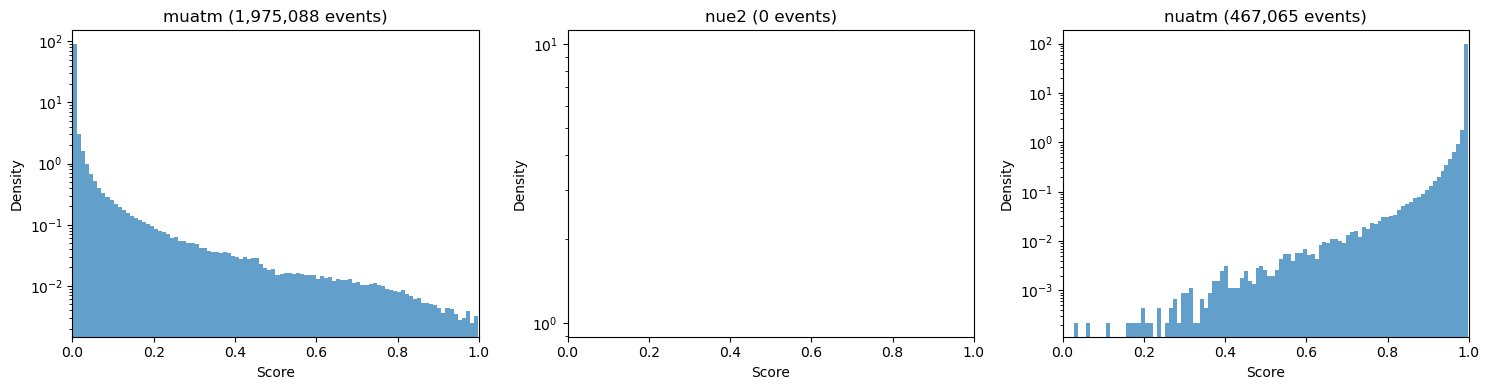

Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260430_0846_Qclip_hardlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_test_mcexpreco/preds_distr_mcexp_reco_justh8s3_theta90.png


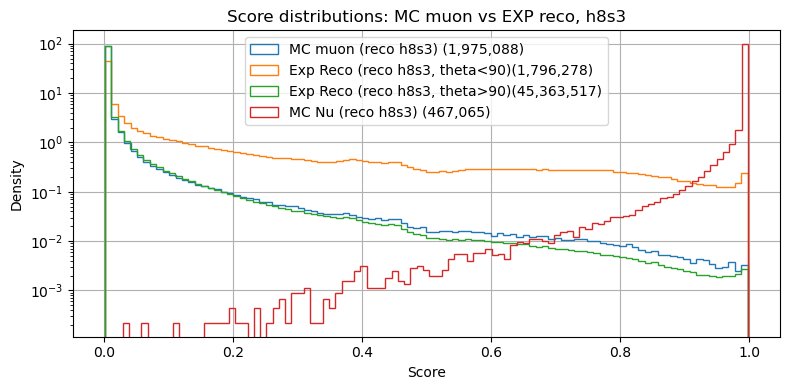

Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260430_0846_Qclip_hardlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_test_mcexpreco/preds_distr_mcexp_reco_justh8s3_theta181.png


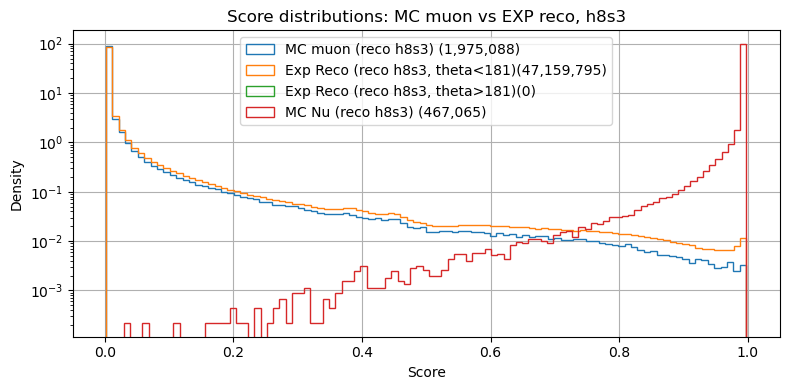

In [11]:
%matplotlib inline
plt.close()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Score distribution per particle type
for ax, ptype in zip(axes, ["muatm", "nue2", "nuatm"]):
    sub = df_mc_scalars[(df_mc_scalars["particle_type"].str.startswith(ptype)) & MASK_BUGS_MC]
    ax.hist(sub["score"], bins=100, alpha=0.7, log=True, density=True)
    ax.set_title(f"{ptype} ({len(sub):,} events)")
    ax.set_xlabel("Score")
    ax.set_ylabel("Density")
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

# Score distribution: MC muons vs MC neutrinos vs Exp
mask = (df_mc_scalars['nHits']>=8) & (df_mc_scalars['nStrings']>=3)
mu = df_mc_scalars[(df_mc_scalars["particle_type"].str.startswith("muatm")) & MASK_BUGS_MC]
nu = df_mc_scalars[(df_mc_scalars["particle_type"].str.startswith("nu")) & MASK_BUGS_MC]

mask = (df_exp_scalars['nHits']>=8) & (df_exp_scalars['nStrings']>=3) # Filter Multi Cluster events artifacts
exp_reco_df0 = df_exp_scalars[mask]


for theta_cut in [90, 181]:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(mu["score"], bins=100, histtype='step', log=True, density=True, label=f"MC muon (reco h8s3) ({len(mu):,})")
    #ax.hist(df_exp["score"], bins=100, alpha=0.5, log=True, density=True, label=f"Exp ({len(df_exp):,})")
    exp_reco_up_score = exp_reco_df0["score"][exp_reco_df0['thetaRec'] < theta_cut]
    exp_reco_down_score = exp_reco_df0["score"][exp_reco_df0['thetaRec'] >= theta_cut]
    ax.hist(exp_reco_up_score, bins=100, histtype='step', log=True, density=True, label=f"Exp Reco (reco h8s3, theta<{theta_cut})({sum(~pd.isna(exp_reco_up_score)):,})")
    ax.hist(exp_reco_down_score, bins=100, histtype='step', log=True, density=True, label=f"Exp Reco (reco h8s3, theta>{theta_cut})({sum(~pd.isna(exp_reco_down_score)):,})")
    ax.hist(nu["score"], bins=100, histtype='step', log=True, density=True, label=f"MC Nu (reco h8s3) ({len(nu):,})")
    ax.set_xlabel("Score")
    ax.set_ylabel("Density")
    ax.legend()
    ax.set_title("Score distributions: MC muon vs EXP reco, h8s3")
    ax.grid()
    plt.tight_layout()
    save_figure(fig, f"preds_distr_mcexp_reco_justh8s3_theta{theta_cut}.png")
    plt.show()


In [12]:
df_mc_scalars

,particle_type,h5_part_str,local_id,n_hits,max_q,mean_z,n_signal_hits_gt,n_signal_strings_gt,theta_mc,phi_mc,...,nCalls,classBDT,classBDTLowE,xyzRec_x,xyzRec_y,xyzRec_z,dirRec_x,dirRec_y,dirRec_z,score
279137,muatm,part_2020_cl2_run10000_scl_nu_MC_s19-21,0,76,102.027641,19.376216,16,5,130.410507,249.805756,...,153.0,-2.0,-2.0,44.372791,-3.020830,-11.816494,-0.195116,-0.831506,-0.520122,0.002326
279138,muatm,part_2020_cl2_run10000_scl_nu_MC_s19-21,1,59,13.693585,12.189770,9,5,120.538651,272.462036,...,152.0,-2.0,-2.0,33.142849,-36.872822,44.486660,-0.538361,-0.800749,-0.262619,0.005985
279139,muatm,part_2020_cl2_run10000_scl_nu_MC_s19-21,2,77,48.027576,81.678743,9,3,120.387009,351.100952,...,72.0,-2.0,-2.0,53.359333,-61.501659,113.152313,0.872075,-0.117434,-0.475074,0.001725
279140,muatm,part_2020_cl2_run10000_scl_nu_MC_s19-21,3,72,48.174931,-2.342729,22,5,153.969620,312.204407,...,67.0,-2.0,-2.0,0.454274,-20.207386,8.481590,0.283488,-0.365716,-0.886502,0.002006
279141,muatm,part_2020_cl2_run10000_scl_nu_MC_s19-21,4,50,4.719494,-0.046421,7,2,171.960526,151.671783,...,249.0,-2.0,-2.0,9.223780,-56.887791,5.061385,-0.061377,-0.098323,-0.993260,0.002175
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3228590,nuatm_conv,part_2020_cl7_run989_scl_nu_MC_s19-21,50,100,6.492681,64.163237,9,2,25.504303,273.879333,...,96.0,-2.0,-2.0,-268.413635,123.110313,120.420090,0.242205,-0.355103,0.902906,0.996161
3228591,nuatm_conv,part_2020_cl7_run989_scl_nu_MC_s19-21,51,1,0.861549,-263.133942,0,0,23.011032,341.411377,...,144.0,-2.0,-2.0,-252.620514,192.450455,100.401947,0.389763,0.031460,0.920377,0.365182
3228592,nuatm_conv,part_2020_cl7_run989_scl_nu_MC_s19-21,52,97,10.054299,51.195177,8,2,23.011032,341.411377,...,144.0,-2.0,-2.0,-252.620514,192.450455,100.401947,0.389763,0.031460,0.920377,0.996841
3228593,nuatm_conv,part_2020_cl7_run989_scl_nu_MC_s19-21,53,1,1.572718,-263.133942,0,0,16.128662,259.497711,...,127.0,-2.0,-2.0,-253.388870,204.802841,-17.667376,-0.227939,-0.199807,0.952954,0.366697
